In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def Oswald_efficiency_factor(AR):
    # Empirical formula for Oswald efficiency factor
    e = 1.78*(1 - 0.045*AR**0.68) - 0.64;
    e = max(min(e,0.92),0.80)  # Limit e to the range [0.80, 0.92];
    return e


In [5]:
def best_glide_velocity(AR, b, W, rho, CD0):
    S = b**2 / AR
    e = Oswald_efficiency_factor(AR)
    k = 1 / (np.pi * e * AR)

    CL_best = np.sqrt(CD0 / k)

    V_bg = np.sqrt((2 * W) / (rho * S * CL_best))

    return V_bg, S, CL_best, k

In [6]:
# Given aircraft data
b = 15.0         # wingspan, m
m = 280.0        # mass, kg
g = 9.81          # gravity, m/s^2
rho = 1.225       # air density at sea level, kg/m^3

W = m * g         # aircraft weight, N

CD0 = (0.012+0.015)/2  # Zero-lift drag coefficient.

# Target best glide velocity
V_target = float(input("Enter the target best glide velocity (m/s): "))


AR_values = np.linspace(3, 40, 1000)  # Aspect ratio range from 3 to 40

results = []

for AR in AR_values:
    V_bg, S, CL_best, k = best_glide_velocity(AR, b, W, rho, CD0)
    
    error = abs(V_bg - V_target)
    
    results.append([AR, V_bg, S, CL_best, k, error])

results = np.array(results)

best_index = np.argmin(results[:, 5])

AR_opt = results[best_index, 0]
V_bg_opt = results[best_index, 1]
S_opt = results[best_index, 2]
CL_best_opt = results[best_index, 3]
k_opt = results[best_index, 4]

print("Optimized Results")
print("-----------------")
print(f"Target best glide velocity     = {V_target:.2f} m/s")
print(f"Calculated best glide velocity = {V_bg_opt:.2f} m/s , {V_bg_opt*3.6:.2f} km/h")
print(f"Optimal Aspect Ratio AR        = {AR_opt:.2f}")
print(f"Wing area S                    = {S_opt:.2f} m²")
print(f"Mean chord c                   = {S_opt / b:.3f} m")
print(f"CL at best glide               = {CL_best_opt:.3f}")
print(f"Induced drag factor k          = {k_opt:.5f}")
print(f"Wing loading W/S               = {W / S_opt:.2f} N/m²")
print(f"e = {Oswald_efficiency_factor(AR_opt):.2f}")

Optimized Results
-----------------
Target best glide velocity     = 22.00 m/s
Calculated best glide velocity = 22.00 m/s , 79.19 km/h
Optimal Aspect Ratio AR        = 20.00
Wing area S                    = 11.25 m²
Mean chord c                   = 0.750 m
CL at best glide               = 0.824
Induced drag factor k          = 0.01989
Wing loading W/S               = 244.16 N/m²
e = 0.80


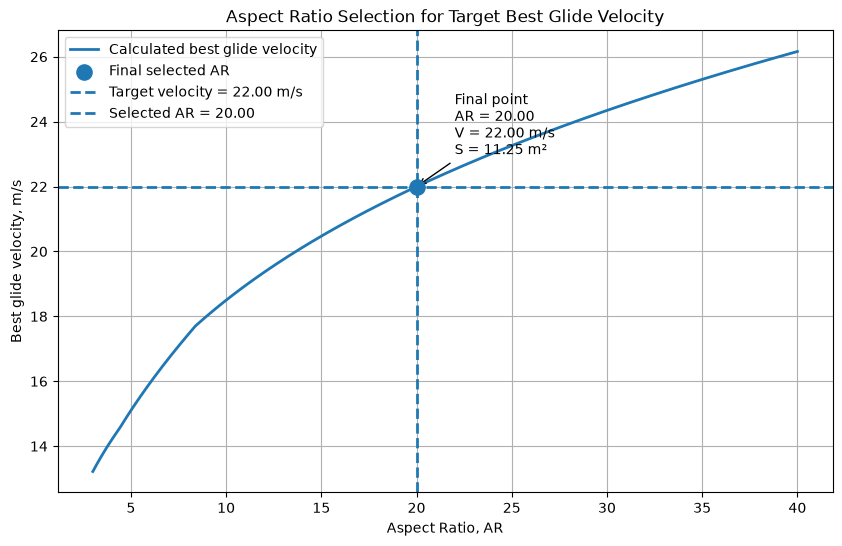

In [7]:
plt.figure(figsize=(10,6))

# Plot all calculated results
plt.plot(results[:,0], results[:,1], linewidth=2, label="Calculated best glide velocity")

# Highlight final selected point
plt.scatter(AR_opt, V_bg_opt, s=120, zorder=5, label="Final selected AR")

# Target velocity line
plt.axhline(V_target, linestyle="--", linewidth=2, label=f"Target velocity = {V_target:.2f} m/s")

# Optimum AR line
plt.axvline(AR_opt, linestyle="--", linewidth=2, label=f"Selected AR = {AR_opt:.2f}")

# Add text label near optimum point
plt.annotate(
    f"Final point\nAR = {AR_opt:.2f}\nV = {V_bg_opt:.2f} m/s\nS = {S_opt:.2f} m²",
    xy=(AR_opt, V_bg_opt),
    xytext=(AR_opt + 2, V_bg_opt + 1),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xlabel("Aspect Ratio, AR")
plt.ylabel("Best glide velocity, m/s")
plt.title("Aspect Ratio Selection for Target Best Glide Velocity")
plt.grid(True)
plt.legend()
plt.show()              





                 GLIDER POLAR RESULTS

Best-glide condition
Best-glide velocity           = 21.998 m/s
Sink rate at best glide       = 0.721 m/s
Best glide angle              = 1.877 degrees
Maximum glide ratio           = 30.510:1
Theoretical maximum L/D       = 30.510

Minimum-sink condition
Minimum-sink velocity         = 16.715 m/s
Minimum sink rate             = 0.633 m/s


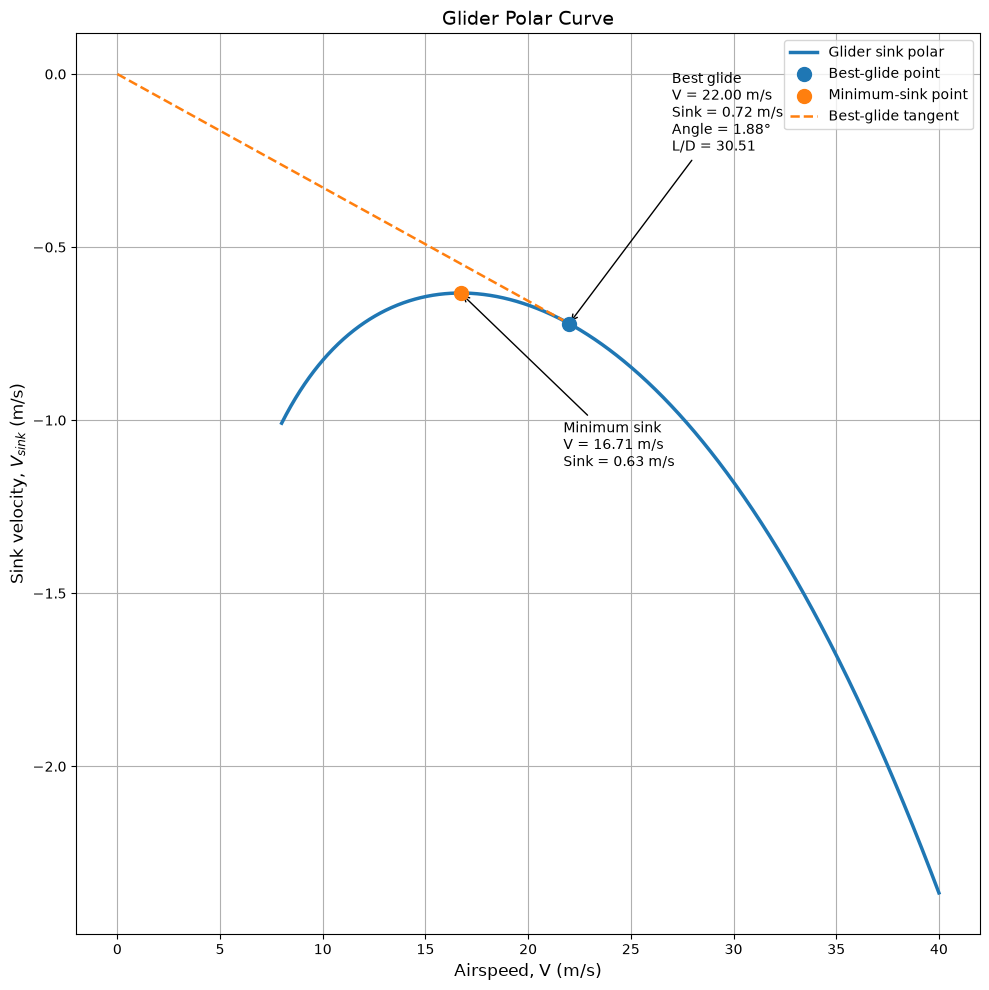

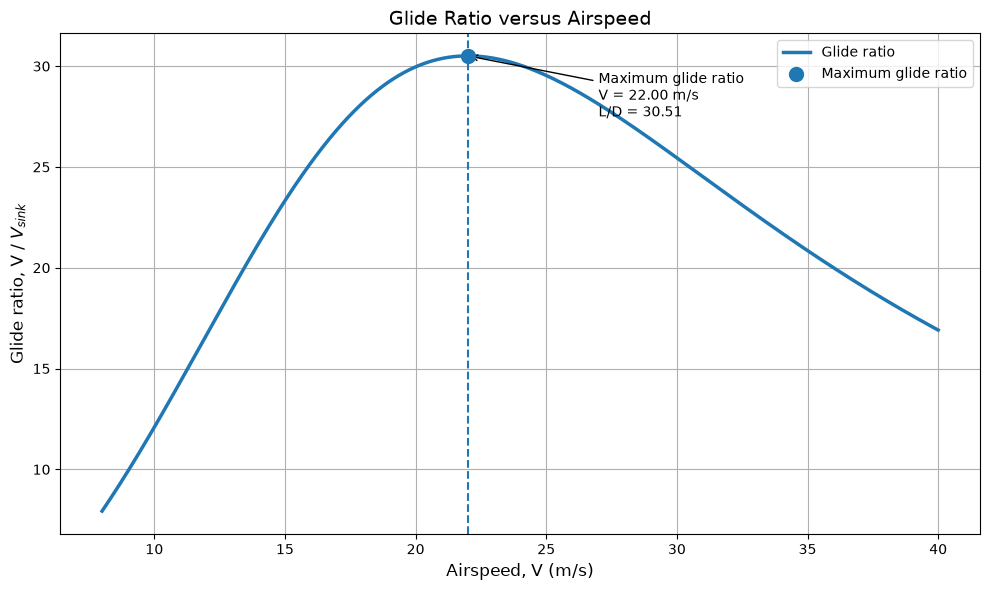

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import math


# ============================================================
#                    USER INPUTS
# ============================================================

rho = 1.225          # Air density, kg/m^3
S = S_opt            # Wing reference area, m^2
AR = AR_opt          # Wing aspect ratio
e = Oswald_efficiency_factor(AR_opt)            # Oswald efficiency factor


# Airspeed range for plotting
V_min = 8.0          # Minimum plotted velocity, m/s
V_max = 40.0        # Maximum plotted velocity, m/s
number_of_points = 1000


# ============================================================
#                    BASIC CALCULATIONS
# ============================================================

# Sink-polar coefficients
A = (rho * S * CD0) / (2 * W)

B = (2 * W) / (np.pi * AR * e * rho * S)


# ============================================================
#              ANALYTICAL OPTIMUM VELOCITIES
# ============================================================

# Best-glide velocity:
# Maximum L/D or minimum glide angle
V_best_glide = (B / A) ** 0.25

# Sink rate at best-glide velocity
Vsink_best_glide = (
    A * V_best_glide**3
    + B / V_best_glide
)

# Minimum-sink velocity
V_min_sink = (B / (3 * A)) ** 0.25

# Minimum sink rate
Vsink_minimum = (
    A * V_min_sink**3
    + B / V_min_sink
)


# ============================================================
#                GLIDE ANGLE AND GLIDE RATIO
# ============================================================

# Exact glide angle based on the velocity components
glide_angle_rad = np.arctan(
    Vsink_best_glide / V_best_glide
)

glide_angle_deg = np.degrees(glide_angle_rad)

# Horizontal distance travelled per unit altitude lost
glide_ratio = V_best_glide / Vsink_best_glide

# Theoretical maximum L/D from drag polar
K = 1 / (np.pi * AR * e)

LD_max_theoretical = 1 / (
    2 * np.sqrt(CD0 * K)
)


# ============================================================
#               GENERATE GLIDER POLAR CURVE
# ============================================================

V = np.linspace(V_min, V_max, number_of_points)

Vsink = A * V**3 + B / V

# Glide angle at every velocity
glide_angle = np.degrees(np.arctan(Vsink / V))

# Glide ratio at every velocity
glide_ratio_curve = V / Vsink


# ============================================================
#                    DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 60)
print("                 GLIDER POLAR RESULTS")
print("=" * 60)

# print(f"Aircraft mass                 = {mass:.3f} kg")
# print(f"Aircraft weight               = {W:.3f} N")
# print(f"Wing area                     = {S:.3f} m²")
# print(f"Aspect ratio                  = {AR:.3f}")
# print(f"Oswald efficiency factor      = {e:.3f}")
# print(f"Zero-lift drag coefficient    = {CD0:.5f}")

# print("\nSink-polar coefficients")
# print(f"A coefficient                 = {A:.8e}")
# print(f"B coefficient                 = {B:.8e}")

print("\nBest-glide condition")
print(f"Best-glide velocity           = {V_best_glide:.3f} m/s")
print(f"Sink rate at best glide       = {Vsink_best_glide:.3f} m/s")
print(f"Best glide angle              = {glide_angle_deg:.3f} degrees")
print(f"Maximum glide ratio           = {glide_ratio:.3f}:1")
print(f"Theoretical maximum L/D       = {LD_max_theoretical:.3f}")

print("\nMinimum-sink condition")
print(f"Minimum-sink velocity         = {V_min_sink:.3f} m/s")
print(f"Minimum sink rate             = {Vsink_minimum:.3f} m/s")

print("=" * 60)


# ============================================================
#                   GLIDER POLAR PLOT
# ============================================================

plt.figure(figsize=(10, 10))

plt.plot(
    V,
    -Vsink,
    linewidth=2.5,
    label="Glider sink polar"
)

# Best-glide point
plt.scatter(
    V_best_glide,
    -Vsink_best_glide,
    s=100,
    zorder=5,
    label="Best-glide point"
)

# Minimum-sink point
plt.scatter(
    V_min_sink,
    -Vsink_minimum,
    s=100,
    zorder=5,
    label="Minimum-sink point"
)

# Best-glide tangent line from origin
V_tangent = np.linspace(0, V_best_glide, 100)

tangent_slope = Vsink_best_glide / V_best_glide

Vsink_tangent = tangent_slope * V_tangent

plt.plot(
    V_tangent,
    -Vsink_tangent,
    linestyle="--",
    linewidth=1.8,
    label="Best-glide tangent"
)

# Best-glide annotation
plt.annotate(
    f"Best glide\n"
    f"V = {V_best_glide:.2f} m/s\n"
    f"Sink = {Vsink_best_glide:.2f} m/s\n"
    f"Angle = {glide_angle_deg:.2f}°\n"
    f"L/D = {glide_ratio:.2f}",
    xy=(V_best_glide, -Vsink_best_glide),
    xytext=(V_best_glide + 5, -Vsink_best_glide + 0.5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Minimum-sink annotation
plt.annotate(
    f"Minimum sink\n"
    f"V = {V_min_sink:.2f} m/s\n"
    f"Sink = {Vsink_minimum:.2f} m/s",
    xy=(V_min_sink, -Vsink_minimum),
    xytext=(V_min_sink + 5, -Vsink_minimum - 0.5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xlabel("Airspeed, V (m/s)", fontsize=12)
plt.ylabel("Sink velocity, $V_{sink}$ (m/s)", fontsize=12)
plt.title("Glider Polar Curve", fontsize=14)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
#                  GLIDE RATIO PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    V,
    glide_ratio_curve,
    linewidth=2.5,
    label="Glide ratio"
)

plt.scatter(
    V_best_glide,
    glide_ratio,
    s=100,
    zorder=5,
    label="Maximum glide ratio"
)

plt.axvline(
    V_best_glide,
    linestyle="--",
    linewidth=1.5
)

plt.annotate(
    f"Maximum glide ratio\n"
    f"V = {V_best_glide:.2f} m/s\n"
    f"L/D = {glide_ratio:.2f}",
    xy=(V_best_glide, glide_ratio),
    xytext=(V_best_glide + 5, glide_ratio - 3),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xlabel("Airspeed, V (m/s)", fontsize=12)
plt.ylabel("Glide ratio, V / $V_{sink}$", fontsize=12)
plt.title("Glide Ratio versus Airspeed", fontsize=14)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


             DRAG POLAR RESULTS
Zero-lift drag coefficient, CD0  = 0.01350
Aspect ratio, AR                 = 20.000
Oswald efficiency factor, e      = 0.8000
Induced-drag factor, k           = 0.01989

------------ MAXIMUM CL/CD -------------------
CL at maximum CL/CD              = 0.8244
CD at maximum CL/CD              = 0.02702
Maximum CL/CD                    = 30.51
Corresponding glide angle        = 1.877 deg


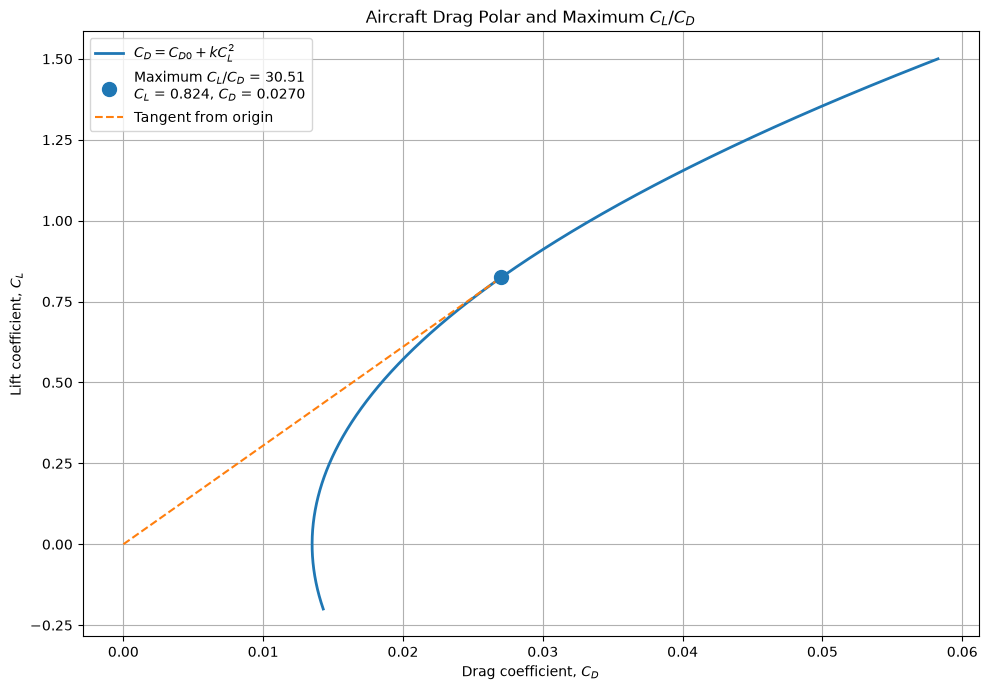

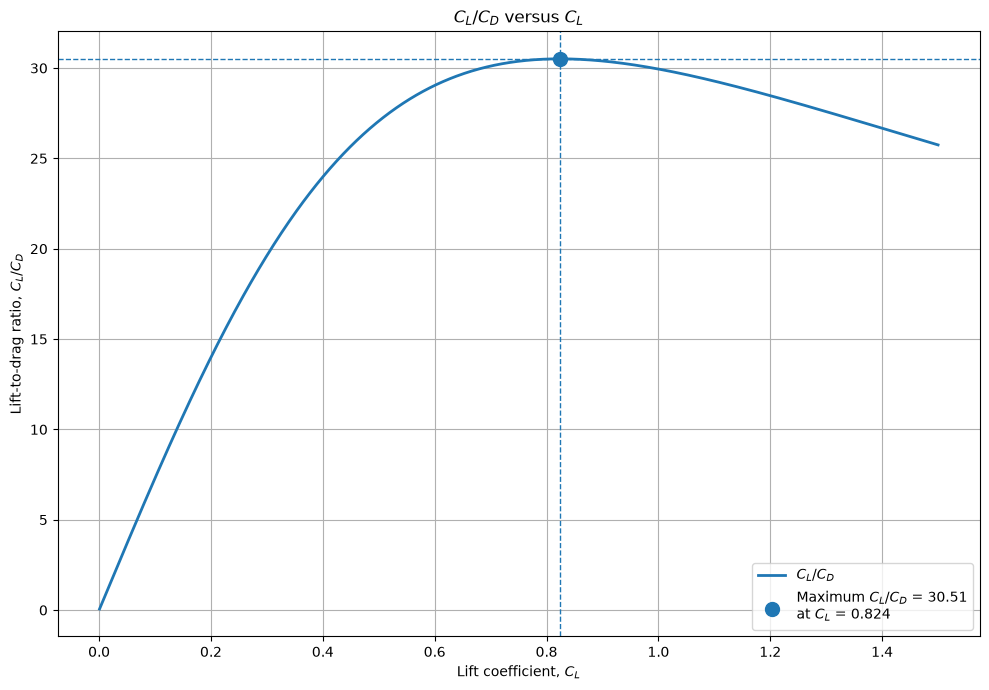

In [9]:
# ============================================================
# AIRCRAFT DRAG POLAR


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# INPUTS
# ============================================================

CL_min = -0.2        # Minimum lift coefficient for plot
CL_max = 1.5         # Maximum lift coefficient for plot
number_of_points = 1000

# ============================================================
# INDUCED-DRAG FACTOR
# ============================================================

k = k_opt  # Induced-drag factor


# ============================================================
# CREATE CL RANGE
# ============================================================

CL = np.linspace(CL_min, CL_max, number_of_points)


# ============================================================
# DRAG POLAR
# ============================================================

CD = CD0 + k * CL**2


# ============================================================
# LIFT-TO-DRAG RATIO
# ============================================================

# Calculate CL/CD only for positive CL.
CL_CD = np.full_like(CL, np.nan)

positive_CL = CL > 0
CL_CD[positive_CL] = CL[positive_CL] / CD[positive_CL]


# ============================================================
# NUMERICAL MAXIMUM CL/CD
# ============================================================

maximum_index = np.nanargmax(CL_CD)

CL_at_maximum_CL_CD = CL[maximum_index]
CD_at_maximum_CL_CD = CD[maximum_index]
maximum_CL_CD = CL_CD[maximum_index]

glide_angle_rad = np.arctan(1.0 / maximum_CL_CD)
glide_angle_deg = np.degrees(glide_angle_rad)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n==============================================")
print("             DRAG POLAR RESULTS")
print("==============================================")

print(f"Zero-lift drag coefficient, CD0  = {CD0:.5f}")
print(f"Aspect ratio, AR                 = {AR:.3f}")
print(f"Oswald efficiency factor, e      = {e:.4f}")
print(f"Induced-drag factor, k           = {k:.5f}")

print("\n------------ MAXIMUM CL/CD -------------------")

print(
    f"CL at maximum CL/CD              = "
    f"{CL_at_maximum_CL_CD:.4f}"
)

print(
    f"CD at maximum CL/CD              = "
    f"{CD_at_maximum_CL_CD:.5f}"
)

print(
    f"Maximum CL/CD                    = "
    f"{maximum_CL_CD:.2f}"
)

print(
    f"Corresponding glide angle        = "
    f"{glide_angle_deg:.3f} deg"
)



# ============================================================
# PLOT 1: DRAG POLAR — CD VERSUS CL
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    CD,
    CL,
    linewidth=2,
    label=r"$C_D=C_{D0}+kC_L^2$"
)

plt.scatter(
    CD_at_maximum_CL_CD,
    CL_at_maximum_CL_CD,
    s=100,
    zorder=5,
    label=(
        f"Maximum $C_L/C_D$ = {maximum_CL_CD:.2f}\n"
        f"$C_L$ = {CL_at_maximum_CL_CD:.3f}, "
        f"$C_D$ = {CD_at_maximum_CL_CD:.4f}"
    )
)

# Line from origin tangent to drag polar.
tangent_CD = np.linspace(
    0,
    CD_at_maximum_CL_CD,
    100
)

tangent_CL = maximum_CL_CD * tangent_CD

plt.plot(
    tangent_CD,
    tangent_CL,
    linestyle="--",
    linewidth=1.5,
    label="Tangent from origin"
)

plt.xlabel(r"Drag coefficient, $C_D$")
plt.ylabel(r"Lift coefficient, $C_L$")
plt.title(r"Aircraft Drag Polar and Maximum $C_L/C_D$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2: CL/CD VERSUS CL
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    CL,
    CL_CD,
    linewidth=2,
    label=r"$C_L/C_D$"
)

plt.scatter(
    CL_at_maximum_CL_CD,
    maximum_CL_CD,
    s=100,
    zorder=5,
    label=(
        f"Maximum $C_L/C_D$ = {maximum_CL_CD:.2f}\n"
        f"at $C_L$ = {CL_at_maximum_CL_CD:.3f}"
    )
)

plt.axvline(
    CL_at_maximum_CL_CD,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    maximum_CL_CD,
    linestyle="--",
    linewidth=1
)

plt.xlabel(r"Lift coefficient, $C_L$")
plt.ylabel(r"Lift-to-drag ratio, $C_L/C_D$")
plt.title(r"$C_L/C_D$ versus $C_L$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [33]:

def read_xflr5_polar(file_path):
    data = []
    airfoil_name = Path(file_path).stem

    with open(file_path, "r", errors="ignore") as f:
        for line in f:

            if "Calculated polar for:" in line:
                airfoil_name = line.split("Calculated polar for:", 1)[1].strip()

            parts = line.split()

            try:
                nums = [float(x) for x in parts]
            except ValueError:
                continue

            # XFLR5 airfoil polar columns:
            # alpha, CL, CD, CDp, Cm, ...
            if len(nums) >= 5:
                data.append(nums[:5])

    if len(data) == 0:
        raise ValueError("No valid XFLR5 polar data found.")

    data = np.asarray(data, dtype=float)

    alpha = data[:, 0]
    Cl = data[:, 1]
    Cd = data[:, 2]
    Cm = data[:, 4]

    valid = (
        np.isfinite(alpha)
        & np.isfinite(Cl)
        & np.isfinite(Cd)
        & np.isfinite(Cm)
        & (Cd > 0)
    )

    alpha = alpha[valid]
    Cl = Cl[valid]
    Cd = Cd[valid]
    Cm = Cm[valid]

    if len(alpha) < 5:
        raise ValueError("Not enough valid polar points.")

    # Sort by angle of attack
    sort_idx = np.argsort(alpha)

    alpha = alpha[sort_idx]
    Cl = Cl[sort_idx]
    Cd = Cd[sort_idx]
    Cm = Cm[sort_idx]

    # Remove duplicate alpha values if present
    alpha_unique, unique_idx = np.unique(alpha, return_index=True)

    alpha = alpha_unique
    Cl = Cl[unique_idx]
    Cd = Cd[unique_idx]
    Cm = Cm[unique_idx]

    return airfoil_name, alpha, Cl, Cd, Cm


def find_linear_region(alpha, Cl):
    n_points = len(alpha)

    if n_points < 5:
        raise ValueError("At least 5 polar points are required.")

    # Use 20% of data, limited to available points
    window_size = max(5, round(0.20 * n_points))
    window_size = min(window_size, n_points)

    best_score = -np.inf
    best_R2 = None
    best_idx = None
    best_p = None

    for i in range(n_points - window_size + 1):
        idx = np.arange(i, i + window_size)

        p = np.polyfit(alpha[idx], Cl[idx], 1)

        slope = p[0]

        if slope <= 0:
            continue

        Cl_fit = np.polyval(p, alpha[idx])

        SSres = np.sum((Cl[idx] - Cl_fit) ** 2)
        SStot = np.sum((Cl[idx] - np.mean(Cl[idx])) ** 2)

        if SStot <= 0:
            continue

        R2 = 1.0 - SSres / SStot

        # Prefer highly linear regions near alpha = 0 deg
        mean_alpha = np.mean(alpha[idx])
        score = R2 - 0.05 * abs(mean_alpha)

        if score > best_score:
            best_score = score
            best_R2 = R2
            best_idx = idx
            best_p = p

    if best_p is None:
        raise ValueError("Could not identify a valid positive-slope linear region.")

    return best_p, best_idx, best_R2


def interpolate_at_cl(alpha, Cl, Cd, Cm, Cl_target):
    """
    Interpolate alpha, Cd and Cm at a required 2D airfoil Cl.

    Only the pre-stall positive-lift branch is used.
    """

    # Find maximum Cl point as approximate positive stall point
    stall_idx = np.argmax(Cl)

    alpha_branch = alpha[:stall_idx + 1]
    Cl_branch = Cl[:stall_idx + 1]
    Cd_branch = Cd[:stall_idx + 1]
    Cm_branch = Cm[:stall_idx + 1]

    # Keep the useful approximately monotonic positive-slope branch
    dCl = np.gradient(Cl_branch, alpha_branch)
    valid_branch = dCl > 0

    alpha_branch = alpha_branch[valid_branch]
    Cl_branch = Cl_branch[valid_branch]
    Cd_branch = Cd_branch[valid_branch]
    Cm_branch = Cm_branch[valid_branch]

    if len(Cl_branch) < 2:
        raise ValueError("Could not construct a valid pre-stall Cl branch.")

    # Sort by Cl because np.interp requires increasing x values
    sort_idx = np.argsort(Cl_branch)

    Cl_branch = Cl_branch[sort_idx]
    alpha_branch = alpha_branch[sort_idx]
    Cd_branch = Cd_branch[sort_idx]
    Cm_branch = Cm_branch[sort_idx]

    # Remove duplicate Cl values
    Cl_unique, unique_idx = np.unique(Cl_branch, return_index=True)

    Cl_branch = Cl_unique
    alpha_branch = alpha_branch[unique_idx]
    Cd_branch = Cd_branch[unique_idx]
    Cm_branch = Cm_branch[unique_idx]

    if Cl_target < np.min(Cl_branch) or Cl_target > np.max(Cl_branch):
        raise ValueError(
            f"Required section Cl = {Cl_target:.4f} is outside the "
            f"usable pre-stall range "
            f"[{np.min(Cl_branch):.4f}, {np.max(Cl_branch):.4f}]."
        )

    alpha_target = np.interp(Cl_target, Cl_branch, alpha_branch)
    Cd_target = np.interp(Cl_target, Cl_branch, Cd_branch)
    Cm_target = np.interp(Cl_target, Cl_branch, Cm_branch)

    return alpha_target, Cd_target, Cm_target


def process_airfoil(file_path, CL_wing, AR, e):
    if AR <= 0:
        raise ValueError("Aspect ratio must be positive.")

    if not 0 < e <= 1:
        raise ValueError("Oswald efficiency factor e must be between 0 and 1.")

    name, alpha, Cl, Cd, Cm = read_xflr5_polar(file_path)

    best_p, best_idx, best_R2 = find_linear_region(alpha, Cl)

    # 2D airfoil lift-curve slope
    a0_deg = best_p[0]       # 1/deg
    intercept = best_p[1]

    if abs(a0_deg) < 1e-12:
        raise ValueError("Calculated airfoil lift slope is zero.")

    a0_rad = a0_deg * 180.0 / np.pi

    alpha_L0 = -intercept / a0_deg

    # Finite-wing lift-curve slope
    a_wing_deg = a0_deg / (
        1.0 + (57.2958 * a0_deg) / (np.pi * e * AR)
    )

    a_wing_rad = a_wing_deg * 180.0 / np.pi

    # Estimated 3D wing geometric angle of attack
    alpha_wing_req = alpha_L0 + CL_wing / a_wing_deg

    # Approximate section Cl
    # For a first estimate, use section cl approximately equal to wing CL.
    Cl_section_req = CL_wing

    # Obtain 2D airfoil operating point from the polar
    alpha_airfoil_req, Cd_req, Cm_req = interpolate_at_cl(
        alpha, Cl, Cd, Cm, Cl_section_req
    )

    ClCd_req = Cl_section_req / Cd_req

    # Induced drag coefficient
    CDi = CL_wing**2 / (np.pi * e * AR)

    # Simple wing drag estimate
    # Assumes airfoil Cd is representative of average wing profile drag.
    CD_wing = Cd_req + CDi

    # Approximate stall information
    stall_idx = np.argmax(Cl)

    return {
        "name": name,
        "file_path": file_path,

        "alpha": alpha,
        "Cl": Cl,
        "Cd": Cd,
        "Cm": Cm,

        "best_idx": best_idx,
        "best_p": best_p,
        "best_R2": best_R2,

        "a0_deg": a0_deg,
        "a0_rad": a0_rad,
        "alpha_L0": alpha_L0,

        "a_wing_deg": a_wing_deg,
        "a_wing_rad": a_wing_rad,

        "alpha_airfoil_req": alpha_airfoil_req,
        "alpha_wing_req": alpha_wing_req,

        "Cl_req": Cl_section_req,
        "Cd_req": Cd_req,
        "Cm_req": Cm_req,
        "ClCd_req": ClCd_req,

        "CDi": CDi,
        "CD_wing": CD_wing,

        "Cl_max": Cl[stall_idx],
        "alpha_stall": alpha[stall_idx],
    }

In [39]:
n_files = 1

CL_wing = CL_best_opt
AR = AR_opt

results = []

for k in range(n_files):
    print(f"\n--- File {k + 1} of {n_files} ---")

    file_path = input(
        "Enter the path to the XFLR5 polar file: "
    ).strip().strip('"')

    try:
        result = process_airfoil(
            file_path=file_path,
            CL_wing=CL_wing,
            AR=AR,
            e=e
        )

        results.append(result)

        print(f"Processed: {result['name']}")

    except Exception as err:
        print(f"Skipped file because: {err}")

if len(results) == 0:
    raise RuntimeError("No valid airfoil results were calculated.")


print("\n========== FINAL RESULTS ==========")
print(
    f"Wing CL = {CL_wing:.4f}, "
    f"AR = {AR:.2f}, "
    f"e = {e:.4f}"
)

for r in results:
    print("\n----------------------------------")
    print(f"Airfoil: {r['name']}")

    print(
        f"Linear region    = "
        f"{r['alpha'][r['best_idx'][0]]:.2f} to "
        f"{r['alpha'][r['best_idx'][-1]]:.2f} deg"
    )

    print(f"Linear-fit R²    = {r['best_R2']:.6f}")

    print(f"a0              = {r['a0_deg']:.5f} per deg")
    print(f"a0              = {r['a0_rad']:.3f} per rad")

    print(f"alpha_L=0       = {r['alpha_L0']:.3f} deg")

    print(f"Wing slope a    = {r['a_wing_deg']:.5f} per deg")
    print(f"Wing slope a    = {r['a_wing_rad']:.3f} per rad")

    print(
        f"Airfoil alpha    = "
        f"{r['alpha_airfoil_req']:.3f} deg"
    )

    print(
        f"Wing alpha est.  = "
        f"{r['alpha_wing_req']:.3f} deg"
    )
    print("----------------------------------")
    print(f"Section Cl       = {r['Cl_req']:.4f}")
    print(f"Airfoil Cd       = {r['Cd_req']:.5f}")
    print(f"Airfoil Cl/Cd    = {r['ClCd_req']:.2f}")
    print(f"Airfoil Cm       = {r['Cm_req']:.4f}")
    print("----------------------------------")
    print(f"Induced CD       = {r['CDi']:.5f}")
    print(f"Wing CD approx.  = {r['CD_wing']:.5f}")
    print("----------------------------------")
    print(f"Maximum Cl       = {r['Cl_max']:.4f}")
    print(f"Stall alpha      = {r['alpha_stall']:.3f} deg")


--- File 1 of 1 ---
Processed: EPPLER 398 AIRFOIL

========== FINAL RESULTS ==========
Wing CL = 0.8238, AR = 20.00, e = 0.8000

----------------------------------
Airfoil: EPPLER 398 AIRFOIL
Linear region    = -2.50 to 2.50 deg
Linear-fit R²    = 0.999963
a0              = 0.11450 per deg
a0              = 6.561 per rad
alpha_L=0       = -6.136 deg
Wing slope a    = 0.10128 per deg
Wing slope a    = 5.803 per rad
Airfoil alpha    = 1.045 deg
Wing alpha est.  = 1.997 deg
----------------------------------
Section Cl       = 0.8238
Airfoil Cd       = 0.00685
Airfoil Cl/Cd    = 120.34
Airfoil Cm       = -0.1633
----------------------------------
Induced CD       = 0.01350
Wing CD approx.  = 0.02035
----------------------------------
Maximum Cl       = 1.6510
Stall alpha      = 15.000 deg


In [13]:
# ============================================================
# WING LIFT SLOPE, WING AoA, AND WING ZERO-LIFT AoA
# ============================================================

import numpy as np

# ---------------- INPUTS ----------------
a0 = r['a0_deg']           # Airfoil lift-curve slope, per degree
CL_required = CL_best_opt   # Required wing lift coefficient

alpha_airfoil = r['alpha_airfoil_req']  # Airfoil AoA that gives CL_required, degrees


# ---------------- CALCULATIONS ----------------


# Finite-wing lift-curve slope, per radian
a_wing = a0 / (
    1.0 + (a0 * 57.3) / (np.pi * e * AR)
)

# Airfoil zero-lift angle using:
# CL = a0(alpha_airfoil - alpha_L0)
alpha_L0_airfoil = alpha_airfoil - CL_required / a0

# Wing zero-lift angle
# For an untwisted wing with constant airfoil section:
alpha_L0_wing = alpha_L0_airfoil

# Wing AoA required to produce the same CL
alpha_wing = alpha_L0_wing + CL_required / a_wing


# ---------------- OUTPUTS ----------------

print(f"Airfoil lift slope, a0       = {a0:.5f} per deg")

print(f"Wing lift slope, a           = {a_wing:.5f} per deg")

print(f"Airfoil zero-lift AoA        = {alpha_L0_airfoil:.3f} deg")
print(f"Wing zero-lift AoA           = {alpha_L0_wing:.3f} deg")

print(f"Airfoil AoA for CL={CL_required:.4f} = {alpha_airfoil:.3f} deg")
print(f"Wing AoA for CL={CL_required:.4f}    = {alpha_wing:.3f} deg")

Airfoil lift slope, a0       = 0.11104 per deg
Wing lift slope, a           = 0.09857 per deg
Airfoil zero-lift AoA        = -5.007 deg
Wing zero-lift AoA           = -5.007 deg
Airfoil AoA for CL=0.8238 = 2.411 deg
Wing AoA for CL=0.8238    = 3.350 deg


In [36]:
# Wing geometry and Reynolds number calculator

# Fixed design inputs

V = V_bg_opt                # Flight speed, m/s
nu = 1.5111e-5           # Kinematic viscosity, m^2/s

# User input
lambda_ratio = float(input("Enter taper ratio lambda = ct/cr: "))

# Validation
if lambda_ratio <= 0 or lambda_ratio > 1:
    raise ValueError("Taper ratio must be between 0 and 1.")


# Root and tip chords
cr = 2 * S / (b * (1 + lambda_ratio))
ct = lambda_ratio * cr

# Reynolds numbers
Re_root = V * cr / nu
Re_tip = V * ct / nu

# Mean aerodynamic chord
MAC = (2 / 3) * cr * ((1 + lambda_ratio + lambda_ratio**2) / (1 + lambda_ratio))
Re_MAC = V * MAC / nu

# Output
print("\n----- RESULTS -----")
print(f"Wing area, S          = {S:.4f} m^2")
print(f"Taper ratio, lambda   = {lambda_ratio:.4f}")
print(f"Root chord, cr        = {cr:.4f} m")
print(f"Tip chord, ct         = {ct:.4f} m")
print(f"Mean aerodynamic chord= {MAC:.4f} m")
print(f"Root Reynolds number  = {Re_root:.4e}")
print(f"Tip Reynolds number   = {Re_tip:.4e}")
print(f"MAC Reynolds number   = {Re_MAC:.4e}")


----- RESULTS -----
Wing area, S          = 11.2500 m^2
Taper ratio, lambda   = 1.0000
Root chord, cr        = 0.7500 m
Tip chord, ct         = 0.7500 m
Mean aerodynamic chord= 0.7500 m
Root Reynolds number  = 1.0918e+06
Tip Reynolds number   = 1.0918e+06
MAC Reynolds number   = 1.0918e+06


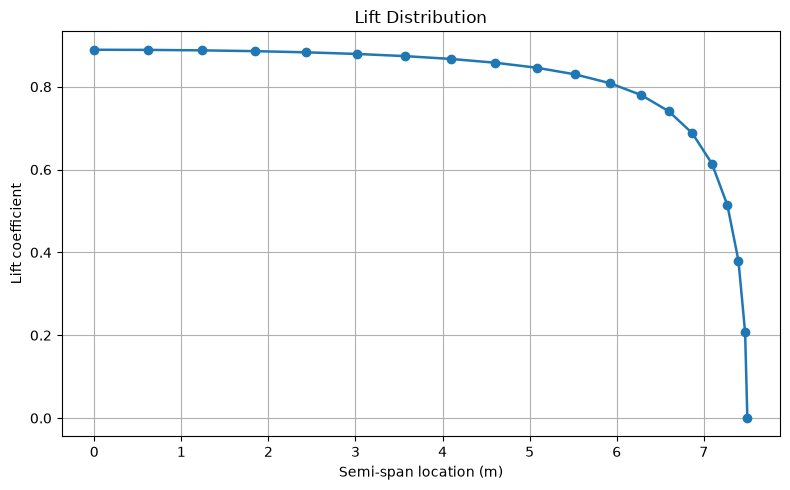

Wing span, b             = 15.000000 m
Mean chord, MAC          = 0.750000 m
Root chord, Croot        = 0.750000 m
Wing lift coefficient    = 0.828338
Lift at 22.00 m/s       = 2762.559206 N
Equivalent supported mass = 281.606443 kg


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Clear previous plots
plt.close("all")

# ====================== INPUTS ======================

N = 19                   # Number of segments - 1
alpha_twist = 0.0       # Twist angle, deg
i_w = alpha_wing              # Wing setting angle, deg
a_2d = a0          # 2D lift-curve slope, 1/rad
alpha_0 = -4.97         # Zero-lift angle of attack, deg

rho = 1.225             # Air density, kg/m^3
V = 22                  # Airspeed, m/s
g = 9.81                # Gravitational acceleration, m/s^2

# ====================== WING GEOMETRY ======================

b = np.sqrt(AR * S)     # Wing span, m
MAC = S / b             # Mean chord used in the original MATLAB code, m

Croot = (
    1.5 * (1 + lambda_ratio) * MAC
    / (1 + lambda_ratio + lambda_ratio**2)
)                       # Root chord, m

# MATLAB:
# theta = pi/(2*N):pi/(2*N):pi/2
theta = np.arange(1, N + 1) * np.pi / (2 * N)

# MATLAB:
# alpha = i_w + alpha_twist : -alpha_twist/(N-1) : i_w
alpha = np.linspace(i_w + alpha_twist, i_w, N)

# Semi-span locations
z = (b / 2) * np.cos(theta)

# Local chord at each segment
c = Croot * (
    1 - (1 - lambda_ratio) * np.cos(theta)
)

# Lifting-line parameter
mu = c * a_2d / (4 * b)

# Left-hand side of lifting-line equations
LHS = mu * (alpha - alpha_0) / 57.3

# ====================== SOLVE FOR FOURIER COEFFICIENTS ======================

B = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        harmonic = 2 * (j + 1) - 1

        B[i, j] = (
            np.sin(harmonic * theta[i])
            * (
                1
                + (
                    mu[i] * harmonic
                    / np.sin(theta[i])
                )
            )
        )

# Equivalent to MATLAB: A = B \ transpose(LHS)
A = np.linalg.solve(B, LHS)

# ====================== LIFT DISTRIBUTION ======================

sum1 = np.zeros(N)
sum2 = np.zeros(N)

for i in range(N):
    for j in range(N):
        harmonic = 2 * (j + 1) - 1

        sum1[i] += (
            harmonic
            * A[j]
            * np.sin(harmonic * theta[i])
        )

        sum2[i] += (
            A[j]
            * np.sin(harmonic * theta[i])
        )

# Local section lift coefficient
CL = 4 * b * sum2 / c

# Add zero lift coefficient at the wing tip
CL1 = np.concatenate(([0.0], CL))

# Add the wing-tip location to the semi-span coordinates
y_s = np.concatenate(([b / 2], z))

# ====================== PLOT ======================

plt.figure(figsize=(8, 5))

plt.plot(
    y_s,
    CL1,
    "-o",
    linewidth=1.8,
    markersize=6
)

plt.grid(True)
plt.title("Lift Distribution")
plt.xlabel("Semi-span location (m)")
plt.ylabel("Lift coefficient")
plt.tight_layout()
plt.show()

# ====================== WING LIFT ======================

CL_wing = np.pi * AR * A[0]

Lift = 0.5 * rho * V**2 * S * CL_wing

weight = Lift / g

# ====================== OUTPUTS ======================

print(f"Wing span, b             = {b:.6f} m")
print(f"Mean chord, MAC          = {MAC:.6f} m")
print(f"Root chord, Croot        = {Croot:.6f} m")
print(f"Wing lift coefficient    = {CL_wing:.6f}")
print(f"Lift at {V:.2f} m/s       = {Lift:.6f} N")
print(f"Equivalent supported mass = {weight:.6f} kg")